# Self-supervised Learning:

Uses rotation prediction as a pretext task
Helps the model learn useful features from unlabeled data

# Few-shot Learning:

Uses only 5 examples per digit class
Transfers knowledge from self-supervised pre-training

# Reinforcement Learning:

Simple environment where actions are digit predictions
Rewards correct classifications and penalizes incorrect ones
Fine-tunes the model based on prediction feedback

In [27]:
# New imports for policy network
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
import numpy as np
from tensorflow.keras import layers, models
import random
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

# Load and preprocess MNIST data
def load_mnist():
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
    x_train = x_train.astype('float32') / 255.0
    x_test = x_test.astype('float32') / 255.0
    x_train = np.expand_dims(x_train, -1)
    x_test = np.expand_dims(x_test, -1)
    return (x_train, y_train), (x_test, y_test)

# Create CNN model
def create_cnn_model():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001),
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])
    return model

# Self-supervised pretraining task (rotation prediction)
def create_self_supervised_data(images):
    rotations = [0, 90, 180, 270]
    x_self = []
    y_self = []
    
    for img in images:
        for i, angle in enumerate(rotations):
            rotated = tf.image.rot90(img, k=i)
            x_self.append(rotated)
            y_self.append(i)
    
    return np.array(x_self), np.array(y_self)

# Few-shot learning support
def create_few_shot_dataset(x_train, y_train, n_shots=5):
    few_shot_x = []
    few_shot_y = []
    
    for digit in range(10):
        digit_indices = np.where(y_train == digit)[0]
        selected_indices = np.random.choice(digit_indices, n_shots, replace=False)
        few_shot_x.extend(x_train[selected_indices])
        few_shot_y.extend(y_train[selected_indices])
    
    return np.array(few_shot_x), np.array(few_shot_y)

# Updated PolicyNetwork class with tensor handling
class PolicyNetwork:
    def __init__(self, base_model):
        self.base_model = base_model
        self.optimizer = Adam(learning_rate=0.001)
        self.loss_fn = SparseCategoricalCrossentropy()
        
    def get_action(self, state, training=False):
        state = tf.convert_to_tensor(state[np.newaxis, ...], dtype=tf.float32)
        logits = self.base_model(state, training=False)
        if training:
            # During training, sample from probability distribution
            action = tf.random.categorical(tf.math.log(logits), 1)[0, 0]
        else:
            # During testing, take most probable action
            action = tf.argmax(logits[0])
        return int(action), logits[0]
    
    @tf.function
    def train_step(self, state, action, reward):
        state = tf.convert_to_tensor(state[np.newaxis, ...], dtype=tf.float32)
        action = tf.convert_to_tensor(action, dtype=tf.int32)
        reward = tf.convert_to_tensor(reward, dtype=tf.float32)
        
        with tf.GradientTape() as tape:
            logits = self.base_model(state, training=True)
            action_mask = tf.one_hot(action, 10)
            log_prob = tf.reduce_sum(action_mask * tf.math.log(logits))
            loss = -log_prob * reward  # Policy gradient loss
            
        # Update model weights
        grads = tape.gradient(loss, self.base_model.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.base_model.trainable_variables))
        return loss

# Updated Environment class
class MNISTEnvironment:
    def __init__(self, x_data, y_data):
        self.x_data = x_data
        self.y_data = y_data
        self.current_index = 0
        self.episode_reward = 0
        self.max_steps = len(x_data)
        
    def reset(self):
        self.current_index = 0
        self.episode_reward = 0
        return self.x_data[self.current_index]
    
    def step(self, action):
        true_label = self.y_data[self.current_index]
        # More nuanced reward structure
        reward = 2.0 if action == true_label else -0.5  # Increase reward contrast
        self.episode_reward += reward
        
        self.current_index += 1
        done = self.current_index >= self.max_steps
        
        next_state = self.x_data[self.current_index] if not done else None
        return next_state, reward, done, true_label


In [28]:
# Load and preprocess data
(x_train, y_train), (x_test, y_test) = load_mnist()

# 1. Self-supervised pre-training
x_self, y_self = create_self_supervised_data(x_train[:5000])  # Increase from 1000 to 5000 samples
self_supervised_model = create_cnn_model()
self_supervised_model.fit(x_self, y_self, epochs=10, batch_size=32, validation_split=0.2)  # Increase epochs to 10


Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.7288 - loss: 0.8052 - val_accuracy: 0.9110 - val_loss: 0.2675
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9377 - loss: 0.1900 - val_accuracy: 0.9283 - val_loss: 0.2040
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9477 - loss: 0.1501 - val_accuracy: 0.9672 - val_loss: 0.0904
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9533 - loss: 0.1397 - val_accuracy: 0.9650 - val_loss: 0.0966
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9583 - loss: 0.1144 - val_accuracy: 0.9615 - val_loss: 0.1056
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9591 - loss: 0.1137 - val_accuracy: 0.9680 - val_loss: 0.0838
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9686 - loss: 0.0903 - val_accuracy: 0.9772 - val_loss: 0.0630
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9742 - loss: 0.0827 - val_accuracy: 0

In [29]:
# 2. Few-shot learning
few_shot_x, few_shot_y = create_few_shot_dataset(x_train, y_train, n_shots=5)
base_model = create_cnn_model()
base_model.set_weights(self_supervised_model.get_weights())
base_model.fit(few_shot_x, few_shot_y, epochs=5, batch_size=32, validation_split=0.2)


Epoch 1/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 276ms/step - accuracy: 0.0708 - loss: 12.7659 - val_accuracy: 0.0000e+00 - val_loss: 19.5942
Epoch 2/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.0437 - loss: 9.2632 - val_accuracy: 0.0000e+00 - val_loss: 14.6869
Epoch 3/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.0604 - loss: 7.2894 - val_accuracy: 0.0000e+00 - val_loss: 12.0504
Epoch 4/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.1313 - loss: 5.8440 - val_accuracy: 0.0000e+00 - val_loss: 10.3675
Epoch 5/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.1854 - loss: 4.2636 - val_accuracy: 0.0000e+00 - val_loss: 9.0814


In [30]:
# 3. Policy Network RL training
env = MNISTEnvironment(x_test[:2000], y_test[:2000])  # Increase test samples
policy = PolicyNetwork(base_model)

episodes = 100  # Increase from 50 to 100
rewards_history = []
accuracy_history = []
best_accuracy = 0
patience = 10
patience_counter = 0

progress_bar = tqdm(range(episodes), desc="Training RL")
for episode in progress_bar:
    state = env.reset()
    done = False
    episode_loss = 0
    correct_predictions = 0
    total_predictions = 0
    
    while not done:
        action, _ = policy.get_action(state, training=True)
        next_state, reward, done, true_label = env.step(action)
        loss = policy.train_step(state, action, reward)
        episode_loss += loss
        
        if action == true_label:
            correct_predictions += 1
        total_predictions += 1
        
        if not done:
            state = next_state
    
    episode_accuracy = correct_predictions / total_predictions
    rewards_history.append(env.episode_reward)
    accuracy_history.append(episode_accuracy)
    
    # Early stopping
    if episode_accuracy > best_accuracy:
        best_accuracy = episode_accuracy
        patience_counter = 0
    else:
        patience_counter += 1
        
    if patience_counter >= patience:
        print(f"\nEarly stopping at episode {episode}")
        break
    
    progress_bar.set_postfix({
        'reward': f'{env.episode_reward:.2f}',
        'acc': f'{episode_accuracy:.2%}',
        'loss': f'{float(episode_loss):.2f}'
    })

# Plot training results
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(rewards_history)
plt.title('Episode Rewards')
plt.xlabel('Episode')
plt.ylabel('Total Reward')

plt.subplot(1, 2, 2)
plt.plot(accuracy_history)
plt.title('Episode Accuracy')
plt.xlabel('Episode')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()


Training RL:   0%|          | 0/100 [00:00<?, ?it/s]

KeyboardInterrupt: 

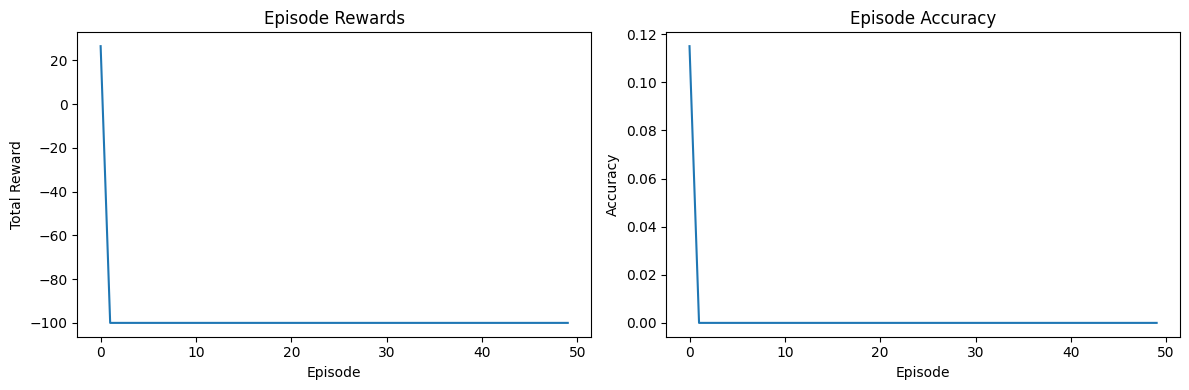

Final Test Accuracy: 9.80%


In [ ]:
# Final evaluation
correct = 0
total = 0
for x, y in zip(x_test, y_test):
    action, _ = policy.get_action(x)
    if action == y:
        correct += 1
    total += 1

print(f"Final Test Accuracy: {correct/total:.2%}")